## Interactive Clustering Tool

### Motivation

This project builds an end-to-end clustering pipeline combining exploratory analysis, hierarchical clustering, K-means segmentation and PCA-based visualisation.

### Usage

Can be used as: 

- An iteractive tool to apply to your data
    
        USE_DEFAULTS = False

- A non-iteractive demo on existing data, comprising 2000 customers in a given distict

        USE_DEFAULTS = True

In [9]:
USE_DEFAULTS = True # Toggle to True to bypass all interactive widgets
DEFAULT_FILE = 'segmentation data.csv'
DEFAULT_THRESH = 0.50
DEFAULT_BRANCHES = 4 

### Import packages and set up

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline
import matplotlib
import matplotlib.ticker as ticker
import os,sys, glob
from IPython.display import HTML, display, clear_output, Markdown, display
import ipywidgets as widgets
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import seaborn as sns
cmap = plt.cm.rainbow
font = 14

### Pre-processing and exploratory analysis

  - Select a dataset 
  
  - Prepare and clean data
  
  - Correlations matrix of feature pairs and list the values above a defined threshold listed


In [11]:
csv_files = glob.glob('*.csv')
if not csv_files:
    csv_files = [DEFAULT_FILE] 
    
dd_file = widgets.Dropdown(options=csv_files, description='Select file:', 
                           value = 'segmentation data.csv', layout={'width': '40%'})

sl_thresh = widgets.FloatSlider(value=0.5, min=0.5, max=1, step=0.05, 
                                description='Correlation threshold:', 
                                layout={'width': '40%'},
                                style={'description_width': 'initial'}, 
                                readout_format='.2f')

def read():
    data = pd.read_csv(dd_file.value)# , index_col = 0)
    initial_rows = len(data)
    data = data.select_dtypes(include=[np.number])
    data = data.dropna()
    final_rows = len(data)
    dropped_rows = initial_rows - final_rows
    if dropped_rows > 0:
        print(f"Warning: Dropped {dropped_rows:,} rows containing NaN values (remaining rows: {final_rows:,})")
    return data

def pre(file,thresh):
    data = read()
    #print(data.head())
    corr = data.corr(numeric_only=True)
    #-------- TOP CORRELATIONS --------#
    thresh = sl_thresh.value
    c = corr.abs().unstack()
    mask = (c.index.get_level_values(0) < c.index.get_level_values(1)) & (c > thresh) 
    top_corr = c[mask].sort_values(ascending=False)
    
    if top_corr.empty:
        print("No pairs above |Pearson r| > %1.2f threshold" %(thresh))
    else:
        print("-" * 55)
        print("Strongest correlations - pairs with |Pearson r| > %1.2f" %(thresh)); 
        print("-" * 55)
        print(top_corr.to_string())
    #----------------------------------#    
    sns.set(font_scale=1.0)
    mask = np.zeros_like(corr, dtype = bool)
    mask[np.triu_indices_from(mask)] = False 

    f, ax = plt.subplots(figsize = (7, 7)) 
    sns.heatmap(corr,annot = False, cmap = cmap, vmin = -1, vmax = 1, 
                mask = mask,square = True, linewidths = 1, ax = ax, 
                cbar_kws={'label': 'Pearson $r$',"shrink": .74})

    plt.title('Pearson correlations between pairs in %s' %(dd_file.value))
    plt.tight_layout()
    #print(dd_file.value);print(data)

if USE_DEFAULTS:
    print("-" * 85)
    print(f"Running in DEFAULT MODE - processing '{DEFAULT_FILE}' with threshold {DEFAULT_THRESH}")
    print("-" * 85)
    print("\nBusiness Problem")
    print("\nCan customer populations be segmented into meaningful behavioural groups to support") 
    print("targeting, pricing, and engagement strategies?\n")
    pre(file=DEFAULT_FILE, thresh=DEFAULT_THRESH)
else:
    spacer = widgets.Box(layout=widgets.Layout(width='50px'))
    controls = widgets.HBox([dd_file, spacer,sl_thresh])
    out = widgets.interactive_output(pre, {'file': dd_file, 'thresh': sl_thresh})
    print("-" * 70)
    print('Dashboard Mode Active: Update selection tools to recompute vectors.')
    print("-" * 70)
    display(controls, out)

----------------------------------------------------------------------
Dashboard Mode Active: Update selection tools to recompute vectors.
----------------------------------------------------------------------


Output()

### Hierarchical Clustering Exploration

Before applying K-means clustering, hierarchical clustering is used to explore the natural structure of the dataset.

The dendrogram provides a visual representation of how observations merge into progressively larger groups. This helps estimate a sensible range for the number of clusters before applying partition-based methods such as K-means.

For larger datasets, a controlled sample is used to maintain computational efficiency while preserving the overall clustering structure.

In [12]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from functools import partial
import ipywidgets as widgets

size = 16
scaler = StandardScaler()
sns.set_style("ticks")

data = read()

size = 16
def elbow(ax, data, branches):
    end = 11 
    wcss = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(data).inertia_ for k in range(1, end)]
    current_wcss = wcss[branches-1]

    ax.plot(range(1, end), wcss, marker='o', ls='-', c='b', lw=2)
    ax.grid(True, alpha=0.3)

    ax.plot([branches, branches], [0, current_wcss], c="r", ls='dotted', lw=2, 
            label='Number of final dendrogram branches')
    
    ax.annotate(f'WCSS: {current_wcss:.3e}', xy=(branches, current_wcss), 
                xytext=(branches + 0.2, current_wcss), 
                color='red', fontweight='bold', fontsize=0.9*size)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Number of Clusters', fontsize=size)
    ax.set_ylabel('WCSS', fontsize=size)
    ax.set_title('K-means Clustering Elbow Plot', fontsize=size)
    ax.legend(fontsize=0.8*size, loc='upper right')

print('Plotting dendrogram - please wait')

def dendo(branches):   
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5)) 
    plt.rcParams.update({'font.size': size})
    
    plt.setp(ax1.spines.values(), linewidth=2)
    ax1.tick_params(direction='in', pad=7, length=6, width=1.5, labelsize=size, 
                    right=True, top=True)

    elbow(ax1, data, branches)
   
    # --------- DENDROGRAM --------- #  
    data_norm = scaler.fit_transform(data) 
    row_count = len(data)
    # If rows exceed 5,000, take a safe sample to calculate matrix linkage distances
    if row_count > 5000:
        np.random.seed(42) # Safe set for consistent plotting
        sample_indices = np.random.choice(data_norm.shape[0], 5000, replace=False)
        data_for_linkage = data_norm[sample_indices]
    else:
        data_for_linkage = data_norm

    hier_clust = linkage(data_for_linkage, method='ward')
    #print(dd_file.value);print(data)
    
    plt.setp(ax2.spines.values(), linewidth=2)
    ax2.tick_params(direction='in', labelsize=size, 
                    pad=7, length=6, width=1.5, right=True, top=True)
    
    dendrogram(hier_clust, truncate_mode='lastp', p=branches, 
               show_leaf_counts=True, no_labels=False, ax=ax2)
    
    ax2.set_title('Hierarchical Clustering Dendrogram - %d final branches' 
                  % (branches), fontsize=size)
    ax2.set_xlabel('Observations', fontsize=size)
    ax2.set_ylabel('Distance', fontsize=size)
    
    plt.tight_layout()
    plt.show()

if USE_DEFAULTS:
    print("-" * 70)
    print(f"Running in DEFAULT MODE: Generating charts using branches = {DEFAULT_BRANCHES}")
    print("-" * 70)
    dendo(branches=DEFAULT_BRANCHES)
else:
    max_limit = min(30, len(data.corr().columns))
    print("-" * 70)
    print(' Dashboard Mode Active: Update selection tools to recompute vectors.')
    print("-" * 70)
    
    print("\nUse the slider below to adjust the number of visible dendrogram branches")
    print("This allows exploration of how the dataset separates into broader or")
    print("finer-grained customer groupings")
    
    sl_branches = widgets.IntSlider(value=3, min=1, max=max_limit, 
        description='No. of final branches for dendrogram:', 
        layout={'width': '60%'}, style={'description_width': 'initial'})

    ui = widgets.HBox([sl_branches])
    out = widgets.interactive_output(dendo, {'branches': sl_branches})
    display(ui, out)

Plotting dendrogram - please wait
----------------------------------------------------------------------
 Dashboard Mode Active: Update selection tools to recompute vectors.
----------------------------------------------------------------------

Use the slider below to adjust the number of visible dendrogram branches
This allows exploration of how the dataset separates into broader or
finer-grained customer groupings


Output()

###  K-Means Clustering

Hierarchical clustering provides an initial view of the dataset structure. K-means clustering is now used to generate explicit customer segments.

The workflow below allows dynamic selection of:
- clustering variables
- number of clusters
- visual comparison dimensions

This enables interactive exploration of how segmentation changes under different assumptions.

------------------------------------------------------------
Running in DEFAULT MODE: Generating charts using 4 clusters
------------------------------------------------------------


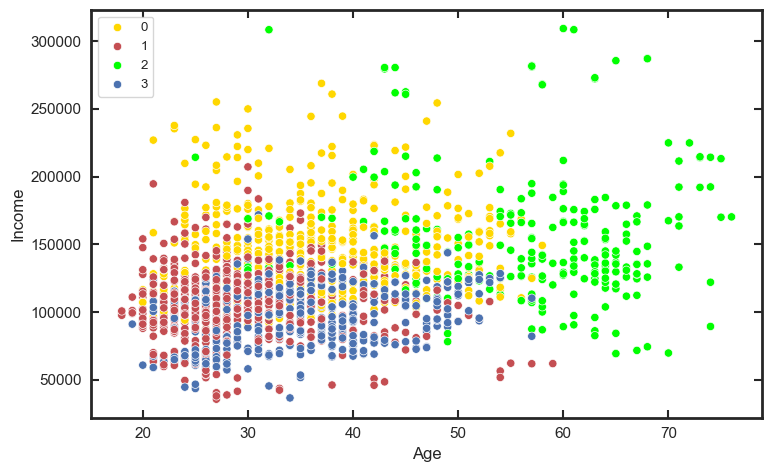

In [5]:
df = read()
cols = df.columns

if USE_DEFAULTS:
    branches=DEFAULT_BRANCHES
else:
    branches=sl_branches.value
    

dd_para1 = widgets.Dropdown(options=cols, value=cols[1], description='x-parameter:', 
                            layout={'width': '30%'}, style={'description_width': 'initial'})
dd_para2 = widgets.Dropdown(options=cols, value=cols[2], description='y-parameter:', 
                            layout={'width': '30%'}, style={'description_width': 'initial'})
sl_clus = widgets.IntSlider(value=branches, min=1, max=len(df.corr().columns), 
                            description='No. of clusters:', 
                            layout={'width': '80%'}, style={'description_width': 'initial'})

palette = ['lime','r','b','gold','orange','g','grey','blueviolet','fuchsia','turquoise','y']
size = 12 

def clus_plot(data, para1, para2, clus, hue_column):
    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    plt.setp(ax.spines.values(), linewidth=2)
    ax.tick_params(direction='in', pad=7, length=6, width=1.5, right=True, top=True)

    unique_labels = data[hue_column].dropna().unique() 
    hue_colors = {label: palette[i % len(palette)] for i, label in enumerate(unique_labels)}
    
    sns.scatterplot(x=para1, y=para2, data=data, hue=hue_column, palette=hue_colors)
    ax.legend(fontsize = 0.8*size,loc='upper left')
    plt.xlabel(para1); plt.ylabel(para2)
    plt.tight_layout()
    plt.show()

def cluster1(data, para1, para2,clus):
    data_norm = scaler.fit_transform(data)
    kmeans = KMeans(n_clusters=clus, init='k-means++', random_state=42) 
    kmeans.fit(data_norm)
    
    global df_kmeans_temp, current_clus_count
    df_kmeans_temp = data.copy()
    df_kmeans_temp['SKM'] = kmeans.labels_
    current_clus_count = clus
    clus_plot(df_kmeans_temp, para1, para2, clus,'SKM')
    return df_kmeans_temp, para1, para2

if USE_DEFAULTS:
    print("-" * 60)
    print(f"Running in DEFAULT MODE: Generating charts using 4 clusters")
    print("-" * 60)
    cluster1(data=df, para1='Age', para2='Income', clus=4)
else:
    wrapped_cluster = partial(cluster1, data=df)
    out = widgets.interactive_output(wrapped_cluster, 
            {'para1': dd_para1, 'para2': dd_para2,'clus': sl_clus})
    spacer = widgets.Box(layout=widgets.Layout(width='50px'))
    ui = widgets.HBox([dd_para1, spacer, dd_para2, spacer, sl_clus])

    print("-" * 85)
    print('- Select axes which give a wide range of scatter in the plot')
    print('- Adjust the cluster count slider to explore different segmentation granularities')
    print('Smaller cluster counts reveal broader population structure, while larger values') 
    
    print("-" * 85)
    display(ui, out)

### Cluster Interpretation

Unsupervised learning identifies statistical groupings, but interpretation is required to translate these into meaningful customer profiles.

The clusters below are labelled based on their relative demographic and behavioural characteristics.

--------------------------------------------------
Running in DEFAULT MODE: Assigning cluster names
--------------------------------------------------

Cluster Interpretation

The analysis identifies four broad customer groups with distinct behavioural
and demographic characteristics

In addition to the 'standard' customer:
 - 'Well-off' customers show high income and larger settlement sizes
 - 'Career focused' customers skew younger with strong occupational indicators
 - 'Fewer opportunities' customers exhibit lower income and reduced engagement metrics
These profiles demonstrate how clustering can support targeted marketing, retention,
and pricing strategies.


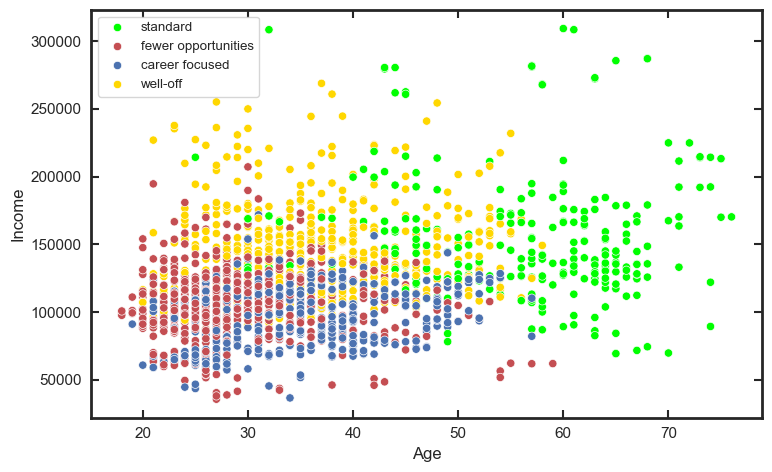

In [6]:
current_clus_count = sl_clus.value

if USE_DEFAULTS:
    n_clusters=4
else:
    n_clusters=current_clus_count

if isinstance(df_kmeans_temp, str):
    # Fallback dataset recovery logic
    data_norm = scaler.transform(df)
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    kmeans.fit(data_norm)
    df_kmeans_temp = df.copy()
    df_kmeans_temp['SKM'] = kmeans.labels_

global dynamic_mapping # WILL NEED IN FOLLOWING CELLS

if USE_DEFAULTS:
    print("-" *50)
    print(f"Running in DEFAULT MODE: Assigning cluster names")
    print("-" * 50)
    
    print('\nCluster Interpretation')
    print('\nThe analysis identifies four broad customer groups with distinct behavioural')
    print('and demographic characteristics')
    print("\nIn addition to the 'standard' customer:")
    print(" - 'Well-off' customers show high income and larger settlement sizes") 
    print(" - 'Career focused' customers skew younger with strong occupational indicators")  
    print(" - 'Fewer opportunities' customers exhibit lower income and reduced engagement metrics") 
    print('These profiles demonstrate how clustering can support targeted marketing, retention')
    print('and pricing strategies.')
    
    current_clus_count = 4 
    dynamic_mapping = {0:'well off',1:'fewer opportunities', 2:'standard', 
                           3:'career focused'}
    df_kmeans_temp['Cluster_Label'] = df_kmeans_temp['SKM'].map(dynamic_mapping)
    clus_plot(df_kmeans_temp, 'Age','Income',current_clus_count, 'Cluster_Label')
    
else:
    current_clus_count = sl_clus.value
    print("Look at the active chart below to guide your custom naming decisions:")
    clus_plot(df_kmeans_temp, dd_para1.value, dd_para2.value, current_clus_count, 
              hue_column='SKM')

    dynamic_mapping = {}
    print(f"\nAssigning custom names for the {current_clus_count} clusters shown above:")

    for cluster in range(current_clus_count):
        user_label = input(f"Enter custom name for Cluster {cluster}: ")
        assigned_label = user_label if user_label.strip() != "" else f"Cluster {cluster}"

        dynamic_mapping[cluster] = assigned_label
        dynamic_mapping[float(cluster)] = assigned_label

    df_a = df_kmeans_temp.groupby(['SKM']).mean(numeric_only=True)
    count_para = df_a.columns[0]
    df_a['N Obs'] = df_kmeans_temp.groupby(['SKM'])[count_para].count()
    df_a['Prop Obs'] = df_a['N Obs'] / df_a['N Obs'].sum()

    df_a_renamed = df_a.rename(index=dynamic_mapping)
    dfc = df_a_renamed.transpose()

    df_kmeans_temp['Cluster_Label'] = df_kmeans_temp['SKM'].map(dynamic_mapping)

    from IPython.display import clear_output
    clear_output(wait=True) 

    print("Custom Cluster Labels Applied Successfully!")
    #print("Final Updated Matrix Table View:"); display(dfc)

    clus_plot(df_kmeans_temp, dd_para1.value, dd_para2.value, 
              current_clus_count, hue_column='Cluster_Label')

### Principal Component Analysis

The original dataset contains multiple correlated variables, making direct visualisation difficult.

*Principal Component Analysis* (PCA) reduces the dimensionality of the dataset while preserving as much variance as possible.

This enables:
- lower-dimensional visualisation
- noise reduction
- improved cluster separation analysis

-------------------------
Running in DEFAULT MODE
-------------------------
---------------------------------------------
Selected Threshold: 80% Explained Variance
Dynamically Using:  4 Principal Components
---------------------------------------------


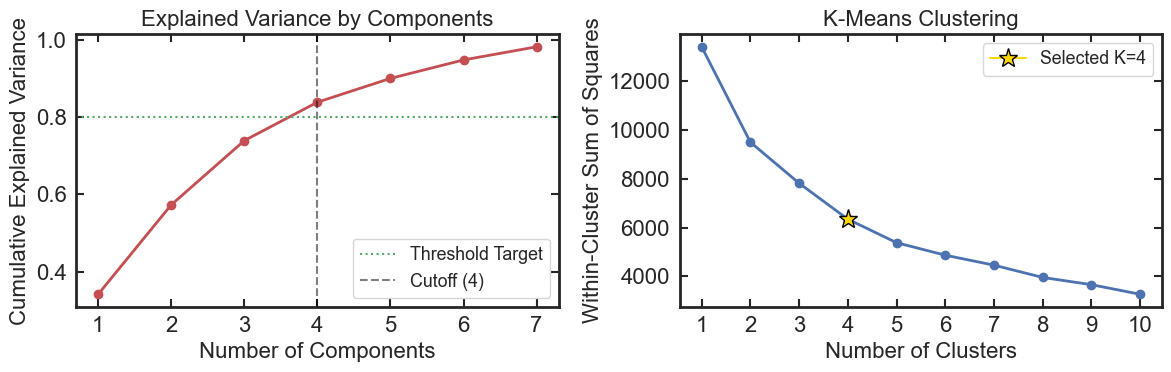

In [7]:
from sklearn.decomposition import PCA

data = df.copy()
data.columns = data.columns.astype(str) # Guarantee string feature columns
data_norm = scaler.fit_transform(data)

n_components = 7 # Maximum baseline limit for your components mapping space

dd_variance = widgets.Dropdown(
    options=[('Manual override', 'manual'), ('70%', 0.70), ('75%', 0.75), 
             ('80%', 0.80), ('85%', 0.85), ('90%', 0.90), 
             ('95%', 0.95), ('99%', 0.99)],
    value=0.80, # Defaults to standard 80% behavior
    description='Target variance threshold:',
    layout={'width': '35%'}, style={'description_width': 'initial'}
)

dd_components = widgets.Dropdown(
    options=[(f'{i} Components', i) for i in range(1, n_components + 1)],
    value=3, # Defaults to 3 components if manual override is selected
    description='Manual component count:',
    layout={'width': '45%'}, style={'description_width': 'initial'}
)

def run_variance_pipeline(target_variance, manual_comps):
    # Pre-fit full footprint to evaluate tracking criteria lines
    pca_full = PCA(n_components=n_components) 
    pca_full.fit(data_norm)
    cum_var = pca_full.explained_variance_ratio_.cumsum()
    
    if target_variance == 'manual':
        no_components = manual_comps
        print("-" * 55)
        print(f"Mode: MANUAL OVERRIDE ACTIVE")
        print(f"Using Hardcoded Selection: {no_components} Principal Components")
        # Pull out the exact amount of variance captured by your manual choice
        captured_var = cum_var[no_components - 1]
        print(f"Total Variance Captured:  {captured_var * 100:.2f}%")
        print("-" * 55)
    else:
        # Standard dynamic lookup logic rule
        if not any(cum_var >= target_variance):
            no_components = n_components
        else:
            no_components = int(np.argmax(cum_var >= target_variance) + 1)
            
        print("-" * 45)
        print(f"Selected Threshold: {target_variance * 100:.0f}% Explained Variance")
        print(f"Dynamically Using:  {no_components} Principal Components")
        print("-" * 45)

    # Re-run the definitive PCA using the targeted 'no_components' count
    pca = PCA(n_components=no_components)
    scores = pca.fit_transform(data_norm)

    global global_df_pca_comp 
    global_df_pca_comp = pd.DataFrame(
        data=pca.components_, columns=data.columns,
        index=[f'Component {i+1}' for i in range(no_components)]
    )

    size = 16
    plt.rcParams.update({'font.size': size})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) 

    # ----- Subplot 1: Cumulative Variance Line Chart -----
    ax1.tick_params(direction='in', labelsize=size, pad=7, length=6, width=1.5, right=True, top=True)
    plt.setp(ax1.spines.values(), linewidth=2)
    ax1.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), cum_var, 
             marker='o', ls='-', c='r', lw=2)

    # Only render target horizontal cutoff bar if not running in manual mode
    if target_variance != 'manual':
        ax1.axhline(y=target_variance, color='g', linestyle=':', label='Threshold Target')
    else:
        ax1.axhline(y=cum_var[no_components - 1], color='orange', linestyle=':', 
                    label='Manual Selection Intercept')
        
    ax1.axvline(x=no_components, color='black', linestyle='--', alpha=0.5, 
                label=f'Cutoff ({no_components})')
    
    ax1.set_title('Explained Variance by Components', fontsize=size)
    ax1.set_xlabel('Number of Components', fontsize=size)
    ax1.set_ylabel('Cumulative Explained Variance', fontsize=size)
    ax1.set_xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
    ax1.legend(loc='lower right', fontsize=0.8*size)

    # ----- Subplot 2: Dynamic WCSS / K-Means Elbow Plot -----
    ax2.tick_params(direction='in', labelsize=size, pad=7, length=6, width=1.5, right=True, top=True)
    plt.setp(ax2.spines.values(), linewidth=2)

    wcss = []
    cluster_range = range(1, 11)
    for k in cluster_range:
        km_model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
        km_model.fit(scores)
        wcss.append(km_model.inertia_)

    ax2.plot(cluster_range, wcss, marker='o', ls='-', c='b', lw=2)
    ax2.set_title('K-Means Clustering', fontsize=size)
    ax2.set_xlabel('Number of Clusters', fontsize=size)
    ax2.set_ylabel('Within-Cluster Sum of Squares', fontsize=size)
    ax2.set_xticks(list(cluster_range))
    
    if USE_DEFAULTS:
        selected_k = 4
    else:
        selected_k = sl_clus.value if 'sl_clus' in globals() else 4

    #selected_k = sl_clus.value
    if selected_k in cluster_range:
        ax2.plot(selected_k, wcss[selected_k - 1], marker='*', c='gold', markersize=14, 
                 markeredgecolor='black', label=f'Selected K={selected_k}')
        ax2.legend(fontsize=0.8*size)
        
    plt.tight_layout()
    plt.show()
    
    # Fixed global assignment structure matching your Option 1 downstream requirement
    global pca_scores, current_components_count
    pca_scores = scores
    current_components_count = no_components

if USE_DEFAULTS:
    print("-" * 25)
    print(f"Running in DEFAULT MODE")
    print("-" * 25)
    run_variance_pipeline(0.8,4)
else:
    print('\nThe controls below allow either:')
    print(' - automatic component selection based on a target explained variance threshold')
    print(' - manual override of the number of retained components')
    print('This provides flexibility between dimensionality reduction efficiency and interpretability')

    
    out_interface = widgets.interactive_output(run_variance_pipeline, 
        {'target_variance': dd_variance, 'manual_comps': dd_components}
    )

    spacer = widgets.Box(layout=widgets.Layout(width='30px'))
    ui_box = widgets.HBox([dd_variance, spacer, dd_components])
    display(ui_box, out_interface)

### Interpretation

The explained variance curve shows how much dataset information is retained as additional principal components are included.

The elbow curve complements this by evaluating clustering compactness under different cluster counts.

Together, these diagnostics help balance:
- dimensionality reduction
- cluster interpretability
- segmentation stability

### PCA-Based Cluster Projection

The final visualisation projects the clustered observations into lower-dimensional PCA space.

Although the original clustering occurs in higher-dimensional feature space, the PCA projection provides an interpretable 2D representation of the customer segments.

Automatically loading cluster names for the selected 4 groups:
   • Cluster 0 -> 'well-off'
   • Cluster 1 -> 'fewer opportunities'
   • Cluster 2 -> 'standard'
   • Cluster 3 -> 'career focused'

DataFrame Preview with Labeled Columns:


,SKM_PCA,Labels,Component 1,Component 2,Component 3,Component 4
0,3,career focused,2.859782,0.936676,2.036586,-1.428485
1,2,standard,0.944130,0.394492,-2.433785,-1.190092
2,0,well-off,-0.023032,-0.881797,1.974083,-2.014387
3,0,well-off,2.212422,-0.563616,0.635332,-0.836900
4,0,well-off,2.110202,-0.425124,1.127543,-1.013575


-------------------------------------------------------------------------------------
Running in DEFAULT MODE - clearer separation of defined groups in just 2 dimensions!
-------------------------------------------------------------------------------------


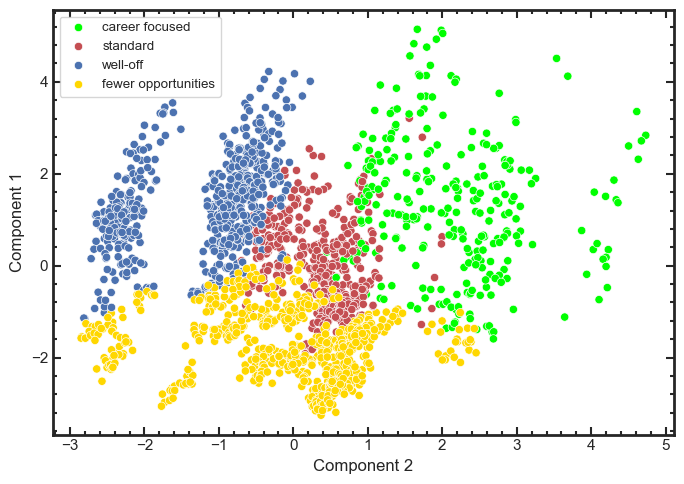

In [8]:
chosen_k = sl_clus.value
chosen_comps = current_components_count
scores_pca = pca_scores.copy()

dic = {}
print(f"Automatically loading cluster names for the selected {chosen_k} groups:")

for cluster in range(chosen_k):
    # Check all possible data formats your dictionary might be using
    if 'dynamic_mapping' in globals():
        if cluster in dynamic_mapping:
            assigned_label = dynamic_mapping[cluster]           # Integer match (e.g., 0)
        elif float(cluster) in dynamic_mapping:
            assigned_label = dynamic_mapping[float(cluster)]    # Float match (e.g., 0.0)
        elif str(cluster) in dynamic_mapping:
            assigned_label = dynamic_mapping[str(cluster)]      # String match (e.g., '0')
        else:
            assigned_label = f"Cluster {cluster}"               # Default fallback if missing
    else:
        assigned_label = f"Cluster {cluster}"                   # Default fallback if dictionary missing
        
    dic[cluster] = assigned_label
    print(f"   • Cluster {cluster} -> '{assigned_label}'")
    

final_km = KMeans(n_clusters=chosen_k, init='k-means++', random_state=42, n_init='auto')
final_labels = final_km.fit_predict(scores_pca)

component_names = [f'Component {i+1}' for i in range(chosen_comps)]
df_scores_matrix = pd.DataFrame(scores_pca, columns=component_names)

df_PCA = pd.concat([data.reset_index(drop=True), df_scores_matrix], axis=1)
df_PCA['SKM_PCA'] = final_labels

df_a = df_PCA.groupby(['SKM_PCA']).mean(numeric_only=True)
df_a['N Obs'] = df_PCA.groupby(['SKM_PCA']).size()
df_a['Prop Obs'] = df_a['N Obs'] / df_a['N Obs'].sum()

# Map names onto your summary matrix table axes and transpose
df_summary_renamed = df_a.rename(index=dic).transpose()
df_PCA['Labels'] = df_PCA['SKM_PCA'].map(dic)

#print("\nFinal Transposed Segmentation Profiles Matrix Table:")
#display(df_summary_renamed)

print("\nDataFrame Preview with Labeled Columns:")
display(df_PCA[['SKM_PCA', 'Labels'] + component_names].head())

dd_comp1 = widgets.Dropdown(
    options=component_names, 
    value=component_names[0] if len(component_names) > 0 else None, 
    description='X Axis Component:', 
    layout={'width': '45%'}, style={'description_width': 'initial'})

dd_comp2 = widgets.Dropdown(
    options=component_names, 
    value=component_names[1] if len(component_names) > 1 else component_names[0], 
    description='Y Axis Component:', 
    layout={'width': '45%'}, style={'description_width': 'initial'})

base_palette = ['lime','r','b','gold','orange','g','grey','blueviolet','fuchsia','turquoise','y']

def sca_pca(para1, para2):
    size = 12
    plt.rcParams.update({'font.size': size})
    
    plt.figure(figsize=(7, 5))
    ax = plt.gca()
    plt.setp(ax.spines.values(), linewidth=2)
    ax.tick_params(direction='in', length=6, width=1.5, which='major', right=True, top=True)
    ax.tick_params(direction='in', length=3, width=1.5, which='minor', right=True, top=True)

    hue = df_PCA['Labels']
    
    # Dynamic slicing of colors prevents look-up scale crashes when using names
    color_slice = base_palette[:chosen_k]
    
    sns.scatterplot(x=para1, y=para2, data=df_PCA, hue=hue, palette=color_slice, ax=ax)
    ax.legend(fontsize=0.8*size)
    
    # Fix minor locator tick calculations to avoid 0-step division warnings
    x_ticks = ax.get_xticks()
    if len(x_ticks) > 1:
        x_min = (x_ticks[1] - x_ticks[0]) / 5
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(x_min))
        
    y_ticks = ax.get_yticks()
    if len(y_ticks) > 1:
        y_min = (y_ticks[1] - y_ticks[0]) / 5
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(y_min))

    plt.xlabel(para1)
    plt.ylabel(para2)
    plt.tight_layout()
    plt.show()
    
if USE_DEFAULTS:
    print("-" * 85)
    print(f"Running in DEFAULT MODE - clearer separation of defined groups in just 2 dimensions!")
    print("-" * 85)
    sca_pca('Component 2','Component 1')
    
else:
    print("-" * 35)
    print('Selected axes')
    print("-" * 35)
    out_pca_plot = widgets.interactive_output(sca_pca, {'para1': dd_comp1, 'para2': dd_comp2})
    ui_plot_box = widgets.HBox([dd_comp1, widgets.Box(layout=widgets.Layout(width='30px')), dd_comp2])
    print("\n📈 Custom Component Visualization Panel:")
    display(ui_plot_box, out_pca_plot)